In [1]:
pip install openpyxl

Defaulting to user installation because normal site-packages is not writeableNote: you may need to restart the kernel to use updated packages.



In [7]:
import pandas as pd
df = pd.read_excel('Book1.xlsx')

print("--- Data Loaded from Excel ---")
print(df)

--- Data Loaded from Excel ---
    ID  Age  Income        City  Spends Buys_Product
0    1   22   25000   Hyderabad    3000           No
1    2   28   42000     Chennai    6000          Yes
2    3   35   52000   Bangalore    9000          Yes
3    4   40   61000   Hyderabad   12000          Yes
4    5   19   18000  Vijayawada    1500           No
5    6   30   45000     Chennai    7000          Yes
6    7   24   28000   Bangalore    3500           No
7    8   33   50000   Hyderabad    8000          Yes
8    9   27   39000       Kochi    5000          Yes
9   10   45   72000   Bangalore   15000          Yes
10  11   38   58000     Chennai   11000          Yes
11  12   21   22000   Hyderabad    2500           No
12  13   29   43000       Kochi    6500          Yes
13  14   26   35000  Vijayawada    4000           No
14  15   32   48000   Hyderabad    7500          Yes
15  16   23   26000     Chennai    3200           No
16  17   37   55000   Bangalore   10000          Yes
17  18   31   4

In [11]:
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

df = pd.read_excel('Book1.xlsx') 

X = df.drop('Buys_Product', axis=1)
y = df['Buys_Product']

imputer = SimpleImputer(strategy='mean')
numerical_cols = ['Age', 'Income', 'Spends']
X[numerical_cols] = imputer.fit_transform(X[numerical_cols])

cat_imputer = SimpleImputer(strategy='most_frequent')
categorical_cols = ['City']
X[categorical_cols] = cat_imputer.fit_transform(X[categorical_cols])

X = pd.get_dummies(X, columns=['City'], prefix='City')

le = LabelEncoder()
y = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

print("Done! Data is ready for the model.")
print(X_train)
print(y_train)

Done! Data is ready for the model.
    ID       Age    Income    Spends  City_Bangalore  City_Chennai  \
8    9 -0.531498 -0.342024 -0.582205           False         False   
5    6 -0.144954  0.035382 -0.082726           False          True   
11  12 -1.304586 -1.411342 -1.206554           False         False   
3    4  1.143526  1.041798  1.165971           False         False   
18  19 -1.433434 -1.537144 -1.381372           False         False   
16  17  0.756982  0.664392  0.666492            True         False   
13  14 -0.660346 -0.593628 -0.831945           False         False   
2    3  0.499286  0.475689  0.416753            True         False   
9   10  1.787766  1.733710  1.915190            True         False   
19  20  1.401222  1.293402  1.415711           False          True   
4    5 -1.562282 -1.662946 -1.456293           False         False   
12  13 -0.273802 -0.090420 -0.207596           False         False   
7    8  0.241590  0.349887  0.167013           False   

In [12]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

# --- STEP 3: CLASSIFICATION MODEL ---

# 1. Initialize the Model
# random_state=42 ensures you get the same result every time you run it
classifier = DecisionTreeClassifier(criterion='entropy', random_state=42)

# 2. Train the Model (The Learning Phase)
# This is where the magic happens. It learns from the 80% data.
classifier.fit(X_train, y_train)

# 3. Make Predictions
# We ask the model to predict answers for the remaining 20% (Test Data)
y_pred = classifier.predict(X_test)

# --- STEP 4: EVALUATION ---

# Calculate Accuracy (How many did it get right?)
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%")

# Confusion Matrix (Where did it get confused?)
# [True Negatives, False Positives]
# [False Negatives, True Positives]
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Model Accuracy: 100.00%

Confusion Matrix:
[[2 0]
 [0 2]]


In [13]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

# --- STEP 3: CLASSIFICATION (RANDOM FOREST) ---

# 1. Initialize the Model
# n_estimators=100 means we are creating 100 decision trees!
# random_state=42 ensures consistent results.
rf_model = RandomForestClassifier(n_estimators=100, criterion='entropy', random_state=42)

# 2. Train the Model (The "Committee" learns)
rf_model.fit(X_train, y_train)

# 3. Make Predictions
y_pred = rf_model.predict(X_test)

# --- STEP 4: EVALUATION ---

accuracy = accuracy_score(y_test, y_pred)
print(f"Random Forest Accuracy: {accuracy * 100:.2f}%")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Random Forest Accuracy: 100.00%

Confusion Matrix:
[[2 0]
 [0 2]]


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Window

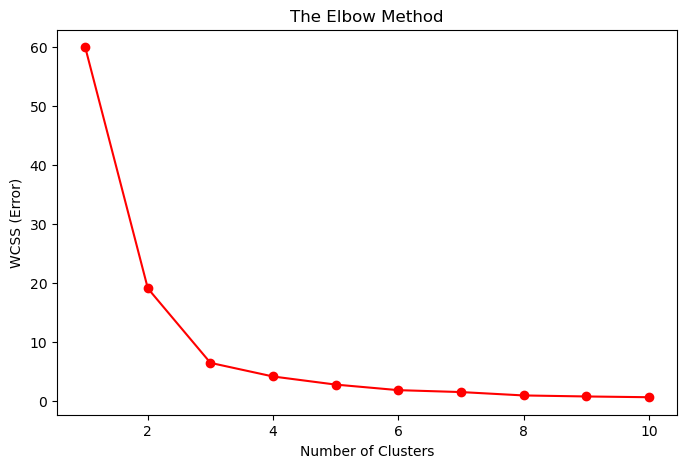

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(



--- Customer Groups Identified ---
   Age  Income  Spends  Cluster_ID
0   22   25000    3000           1
1   28   42000    6000           0
2   35   52000    9000           0
3   40   61000   12000           2
4   19   18000    1500           1


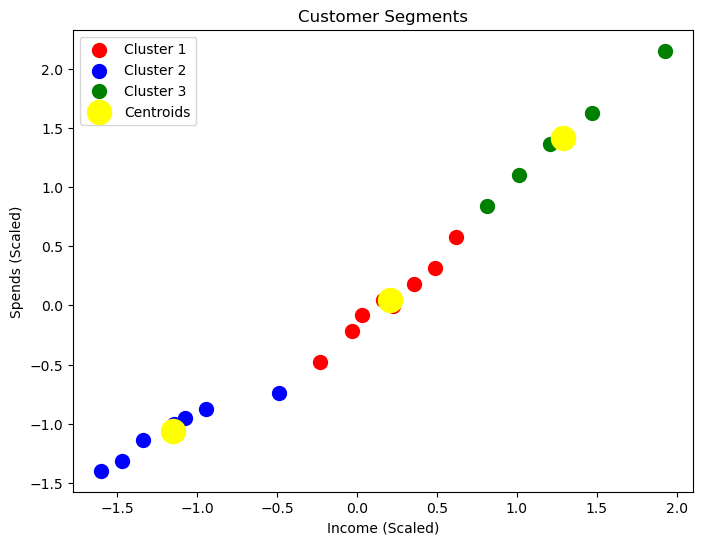

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# --- STEP 1: LOAD DATA ---
df = pd.read_excel('Book1.xlsx')

# --- STEP 2: PREPROCESSING FOR CLUSTERING ---

# A. Select Features (Drop the Target 'Buys_Product' if it exists)
# We usually focus on numerical columns for clean clustering visuals
X = df[['Age', 'Income', 'Spends']] 

# B. Handle Missing Values
imputer = SimpleImputer(strategy='mean')
X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

# C. Scale the Data (CRITICAL for Clustering)
# K-Means calculates "distance". If Income is 50,000 and Age is 30, 
# the model will only care about Income. Scaling fixes this.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --- STEP 3: FINDING THE OPTIMAL CLUSTERS (The Elbow Method) ---
# We try dividing data into 1 to 10 groups and see which fits best.
wcss = [] # Within-Cluster Sum of Square (Error)

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Plotting the Elbow Graph
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o', color='red')
plt.title('The Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS (Error)')
plt.show()
# LOOK AT THE GRAPH: Pick the number where the line bends like an "Elbow" (usually 3 or 4).
# --- STEP 4: APPLY K-MEANS ---

# Let's say we chose 3 clusters
kmeans = KMeans(n_clusters=3, init='k-means++', random_state=42)

# We fit the model and predict the cluster for each person immediately
y_kmeans = kmeans.fit_predict(X_scaled)

# Add the Cluster ID back to your original Excel data so you can see it!
df['Cluster_ID'] = y_kmeans

print("\n--- Customer Groups Identified ---")
print(df[['Age', 'Income', 'Spends', 'Cluster_ID']].head())

# --- STEP 5: VISUALIZE THE CLUSTERS ---
# We plot Income vs Spends to see the groups
plt.figure(figsize=(8, 6))

# Scatter plot for each cluster
# X_scaled columns: 0=Age, 1=Income, 2=Spends
plt.scatter(X_scaled[y_kmeans == 0, 1], X_scaled[y_kmeans == 0, 2], s=100, c='red', label='Cluster 1')
plt.scatter(X_scaled[y_kmeans == 1, 1], X_scaled[y_kmeans == 1, 2], s=100, c='blue', label='Cluster 2')
plt.scatter(X_scaled[y_kmeans == 2, 1], X_scaled[y_kmeans == 2, 2], s=100, c='green', label='Cluster 3')

# Plot Centroids (The center of each group)
plt.scatter(kmeans.cluster_centers_[:, 1], kmeans.cluster_centers_[:, 2], s=300, c='yellow', label='Centroids')

plt.title('Customer Segments')
plt.xlabel('Income (Scaled)')
plt.ylabel('Spends (Scaled)')
plt.legend()
plt.show()